# **Imports**

In [27]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# **Clean and Combine Data**

In [19]:
MATURITIES = {
    '1M':  'DGS1MO.csv',
    '3M':  'DGS3MO.csv',
    '6M':  'DGS6MO.csv',
    '1Y':  'DGS1.csv',
    '2Y':  'DGS2.csv',
    '5Y':  'DGS5.csv',
    '7Y':  'DGS7.csv',
    '10Y': 'DGS10.csv',
    '20Y': 'DGS20.csv',
    '30Y': 'DGS30.csv'
}

# Loads the maturity respective FRED CSV
def load_csv(filepath, col_name):
    file = pd.read_csv(filepath, parse_dates=['observation_date'], index_col='observation_date')
    file.columns = [col_name]
    file[col_name] = pd.to_numeric(file[col_name], errors='coerce')
    return file


def load_all_yields(maturity_dict):
    full_dataset = []
    for label, filename in maturity_dict.items():
        individual_data = load_csv(filename, label)
        full_dataset.append(individual_data)
    combined_data = pd.concat(full_dataset, axis=1, join='outer')
    combined_data.index.name = 'Date'
    combined_data.sort_index(inplace=True)
    return combined_data


raw_data = load_all_yields(MATURITIES)

#print("Percent missing per column")
#print(raw_data.isnull().sum() / len(raw_data) * 100)

def clean_yields(data, max_consec_fill=5):
    cleaned = data.ffill(limit=max_consec_fill)
    cleaned.dropna(how='all', inplace=True)
    threshold = len(cleaned.columns) // 2 # half the columns are NaN
    cleaned.dropna(thresh=threshold, inplace=True)
    return cleaned

yields = clean_yields(raw_data)
yields_only = yields.dropna()

# **Visualization**

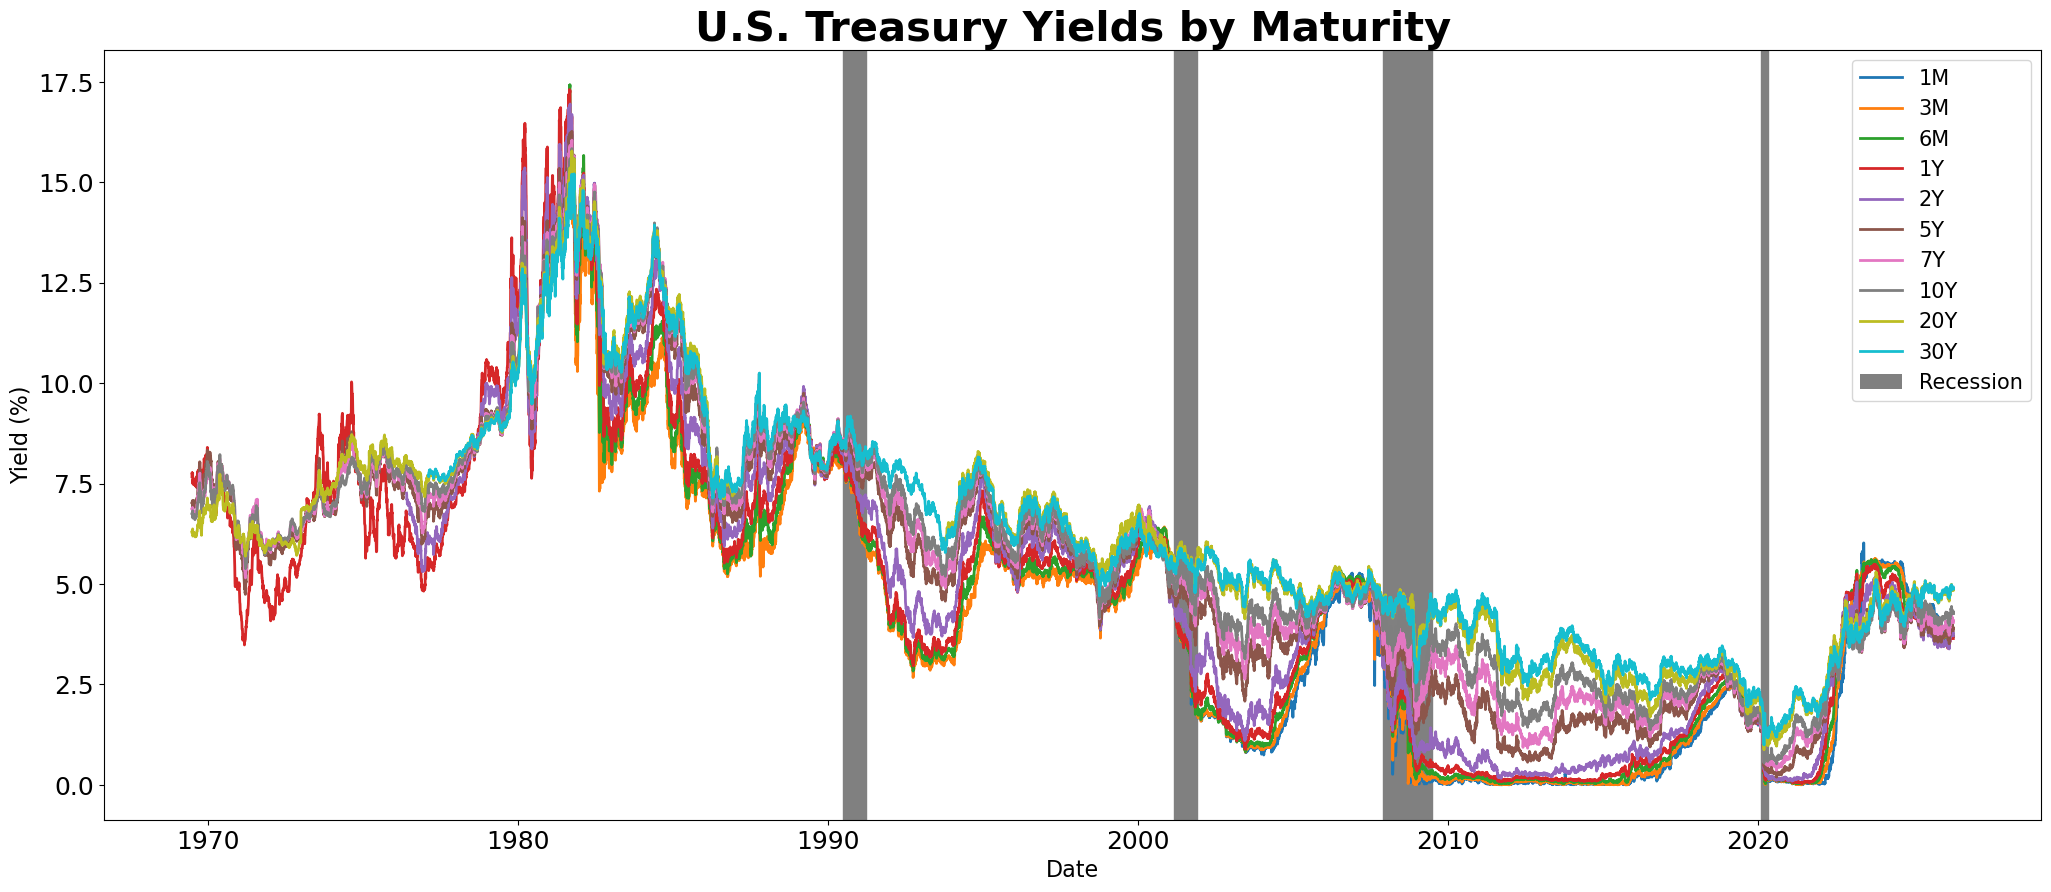

In [53]:
def yields_over_time(data):
    # Wikipedia list of recessions that fall in the date range of dataset
    recessions = [
        ('1990-07-01', '1991-03-31'),
        ('2001-03-01', '2001-11-30'),
        ('2007-12-01', '2009-06-30'),
        ('2020-02-01', '2020-04-30'),
    ]
    fig, ax = plt.subplots(figsize=(25, 10))
    
    for col in data.columns:
        ax.plot(data.index, data[col], linewidth=2, label=col)
    for (start, end) in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='gray', label='_nolegend_')

    ax.tick_params(axis='both', labelsize=18)
    recession_label = Patch(facecolor='gray', label='Recession')
    ax.set_title('U.S. Treasury Yields by Maturity', fontsize=30, fontweight='bold')
    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Yield (%)', fontsize=16)
    ax.legend(handles=[*ax.lines, recession_label], loc='upper right', ncol=1, fontsize=15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.savefig('yields_over_time.png', dpi=150)
    plt.show()

yields_over_time(yields)